<a href="https://colab.research.google.com/github/Faspeice/ml/blob/lr4/lr4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 4
# Многомерная регрессия

**Цель работы**: изучение принципов решения задачи многомерной
регрессии с использованием методов машинного обучения.

Выполним анализ набора данных `Salary Data`. Набор данных содержит информацию о зарплатах сотрудников компании. Смысл задачи - прогнозировать заработную плату сотрудника. Набор данных включает следующие атрибуты:

- **Age** – возраст сотрудника в годах.  
- **Gender** – пол сотрудника.  
- **Education Level** – уровень образования сотрудника (средняя школа, степень бакалавра, степень магистра или доктора философии.  
- **Job Title** – должность сотрудника. Должности могут различаться в зависимо-
сти от компании (менеджер, аналитик, инженер или администратор).  
- **Years of Experience** – количество лет работы сотрудника.  
- **Salary** – годовая зарплата сотрудника в долларах США.  


 ## Импортируем библиотеки и загружаем данные

In [105]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [106]:
url = "https://raw.githubusercontent.com/faspeice/ml/lr4/Salary%20Data.csv"
df = pd.read_csv(url)

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## Получим информацию о датасете

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


## Проверяем наличие пропущенных значений и выбросов

In [108]:
print(df.isnull().sum())

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


In [109]:
df_copy = df.copy()
# Заменим пропуски числовых данных средним арифметическим
numeric_cols = ['Age', 'Years of Experience', 'Salary']

df_copy[numeric_cols] = df[numeric_cols].replace(0, np.nan)
df_copy[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Заменим пропуски категориальный данных наиболее часто встречающимся значением
categorical_cols = ['Gender', 'Education Level', 'Job Title']

for col in categorical_cols:
    mode_value = df[col].mode()
    df_copy[col] = df_copy[col].fillna(mode_value[0])

# убедимся, что пропусков не осталось
print(df_copy.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


## Заменяем категориальные значения числовыми

In [110]:
for col in categorical_cols:
    unique, counts = np.unique(df_copy[col].dropna(), return_counts=True)
    print('\nColumn:', col)
    print('Unique values:', unique)
    print('Counts:', counts)


Column: Gender
Unique values: ['Female' 'Male']
Counts: [179 196]

Column: Education Level
Unique values: ["Bachelor's" "Master's" 'PhD']
Counts: [226  98  51]

Column: Job Title
Unique values: ['Account Manager' 'Accountant' 'Administrative Assistant'
 'Business Analyst' 'Business Development Manager'
 'Business Intelligence Analyst' 'CEO' 'Chief Data Officer'
 'Chief Technology Officer' 'Content Marketing Manager' 'Copywriter'
 'Creative Director' 'Customer Service Manager' 'Customer Service Rep'
 'Customer Service Representative' 'Customer Success Manager'
 'Customer Success Rep' 'Data Analyst' 'Data Entry Clerk' 'Data Scientist'
 'Digital Content Producer' 'Digital Marketing Manager' 'Director'
 'Director of Business Development' 'Director of Engineering'
 'Director of Finance' 'Director of HR' 'Director of Human Capital'
 'Director of Human Resources' 'Director of Marketing'
 'Director of Operations' 'Director of Product Management'
 'Director of Sales' 'Director of Sales and Mar

In [111]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_copy[col] = le.fit_transform(df_copy[col])
    label_encoders[col] = le
df_copy

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,0,0,131,8.0,85000.0
371,43.0,1,1,30,19.0,170000.0
372,29.0,0,0,70,2.0,40000.0
373,34.0,1,0,137,7.0,90000.0


## Разделяем данные на признаки и целевую переменную

In [112]:
y = df_copy['Salary']
X = df_copy.drop('Salary', axis = 1)

X.head()

,Age,Gender,Education Level,Job Title,Years of Experience
0,32.0,1,0,159,5.0
1,28.0,0,1,17,3.0
2,45.0,1,2,130,15.0
3,36.0,0,0,101,7.0
4,52.0,1,1,22,20.0


## Разделяем данные на обучающую и тестовую выборку
80% данных используется для обучения и 20% для тестирования.

In [113]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

## Применяем операцию нормализации для численной устойчивости

In [114]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
scaler = StandardScaler()
scaler

StandardScaler()

## Масштабируем признаки обучающей выборки

In [115]:
X_train_scaled = scaler.fit_transform(X_train)

scaler.mean_, scaler.scale_

(array([37.54287757,  0.52666667,  0.53666667, 90.01333333, 10.12187221]),
 array([ 7.06634224,  0.49928838,  0.74519945, 46.6624741 ,  6.57350643]))

## Обучаем модель линейной регрессии

In [116]:
model = LinearRegression().fit(X_train_scaled, y_train)
model

LinearRegression()

## Делаем прогноз на основе данных тестирования

In [117]:
# преобразуем тестовые данные с использованием среднего и СКО, рассчитанных на обучающей выборке
# так тестовые данные не повляют на обучение модели, и мы избежим утечки данных
X_test_scaled = scaler.transform(X_test)

# сделаем прогноз на стандартизированных тестовых данных
y_pred = model.predict(X_test_scaled)

y_pred[:5]

array([ 60577.84499669, 103092.94562874, 149766.88892601, 110258.06198997,
        85018.28655305])

In [118]:
from sklearn.metrics import root_mean_squared_error

print('Root Mean Squared Error (RMSE):', root_mean_squared_error(y_test, y_pred))

Root Mean Squared Error (RMSE): 11804.71933506854


In [119]:
from sklearn.metrics import r2_score
print('R2:', np.round(r2_score(y_test, y_pred), 2))

R2: 0.93


In [120]:
# оценим R-квадрат
model.score(X_test_scaled, y_test)

0.9277512830712399

## Итоговое уравнение

In [121]:
print('Coefficents: ', model.coef_)

Coefficents:  [19871.50879295  4432.95442076  9783.81631447  1192.89885863
 19806.70262272]


In [122]:
print('Intercept: ', model.intercept_)

Intercept:  101121.68230563002


## Оценим влияние признаков на целевую переменную

In [123]:
# Заменим пропуски числовых данных средним арифметическим
df[numeric_cols] = df[numeric_cols].replace(0, np.nan)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Заменим пропуски категориальный данных наиболее часто встречающимся значением
for col in categorical_cols:
    mode_value = df[col].mode()
    df[col] = df[col].fillna(mode_value[0])
# убедимся, что пропусков не осталось
print(df.isnull().sum())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64


In [124]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0
...,...,...,...,...,...,...
370,35.0,0,0,131,8.0,85000.0
371,43.0,1,1,30,19.0,170000.0
372,29.0,0,0,70,2.0,40000.0
373,34.0,1,0,137,7.0,90000.0


In [125]:
df.corr()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
Age,1.000000,-0.020274,0.561869,0.117093,0.966495,0.922335
Gender,-0.020274,1.000000,-0.048329,0.007532,0.006574,0.070931
Education Level,0.561869,-0.048329,1.000000,0.104495,0.586399,0.669389
Job Title,0.117093,0.007532,0.104495,1.000000,0.091274,0.135585
Years of Experience,0.966495,0.006574,0.586399,0.091274,1.000000,0.921812
Salary,0.922335,0.070931,0.669389,0.135585,0.921812,1.000000


## Визуализация результатов регрессии

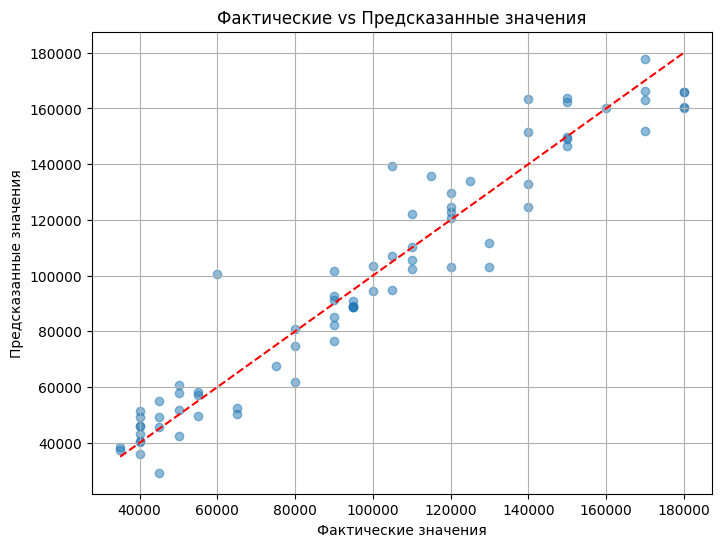

In [126]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Фактические значения")
plt.ylabel("Предсказанные значения")
plt.title("Фактические vs Предсказанные значения")
plt.grid()
plt.show()

По графику видно, что точки распределены вдоль прямой — линейная модель отлично ловит тренд.

## Остатки регрессии (Residuals plot)

Проверим, что остатки случайны и не имеют паттернов.

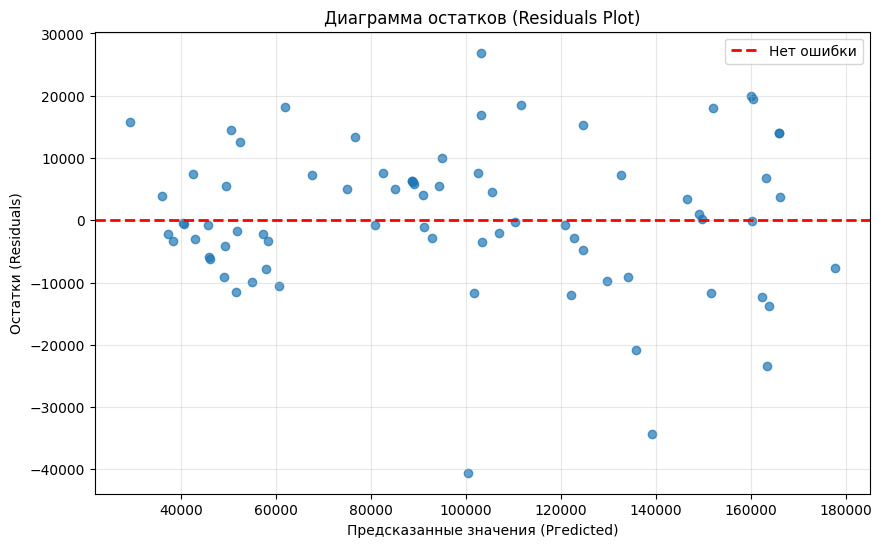

In [127]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
plt.scatter (y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Heт oшибки')
plt.xlabel('Предсказанные значения (Ргedicted)')
plt.ylabel('Oстатки (Residuals)')
plt.title('Диаграмма остатков (Residuals Plot)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Остатки беспорядочно разбросаны вокруг нуля — модель адекватно описывает зависимость в данных.